# Problem Statement: Build a Smart Mutual Fund Advisor

# Part 1: Implement the Solution

## Setup

In [1]:
import gradio as gr
import pandas as pd
import os
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.schema.output_parser import OutputParserException
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from uuid import uuid4
from langgraph.graph import START, StateGraph, END
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver

In [2]:
# Load environment variables and API Keys here
load_dotenv()

# API keys are read from the environment; no keys are hard-coded in the notebook.
if os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

## Defining Components

### Chat Model

In [3]:
# Model name map for UI Mapping
model_name_map = {
    "GPT-OSS-120B": "openai/gpt-oss-120b",
    "GPT-OSS-20B": "openai/gpt-oss-20b",
    "Qwen3.8-27B": "qwen/qwen3.8-27b"
}

model_choices = [
    "GPT-OSS-120B (Groq)",
    "GPT-OSS-20B (Groq)",
    "Qwen3.8-27B (Groq)"
]

In [4]:
# Model Selector
def get_llm(model_choice, temperature):
    if "Groq" in model_choice:
        selected_model = model_choice.split(" (")[0]
        return init_chat_model(
            model_name_map[selected_model],
            model_provider="groq",
            temperature=temperature
        )
    else:
        raise ValueError("Invalid model")

### Embedding Model

In [5]:

embeddings = OllamaEmbeddings(model="all-minilm")

### Vector Store

In [6]:
# Initialize ChromaDB with a persist directory set
persist_directory = "./chroma_db"

vectorstore = Chroma(
    collection_name="mutual_funds",
    embedding_function=embeddings,
    persist_directory=persist_directory
)

## Load and Preprocess Data

In [7]:
# Load and preprocess data
loader = CSVLoader(file_path="mutual_funds_data.csv", source_column="scheme_code")
documents_raw = loader.load()

In [8]:
# Convert page_content string to dict and build metadata
documents = []
for doc in documents_raw:
    try:
        row_data = dict(
            line.split(":", 1) for line in doc.page_content.split("\n") if ":" in line
        )
        row_data = {k.strip(): v.strip() for k, v in row_data.items()}

        # Keep Scheme Name, Fund House, Scheme Type, Scheme Category,
        # Net Asset Value and Date in content
        page_text = (
            f"Scheme Name: {row_data.get('scheme_name', '')}\n"
            f"Fund House: {row_data.get('fund_house', '')}\n"
            f"Scheme Type: {row_data.get('scheme_type', '')}\n"
            f"Scheme Category: {row_data.get('scheme_category', '')}\n"
            f"Net Asset Value: {row_data.get('net_asset_value', '')}\n"
            f"Date: {row_data.get('date', '')}"
        )

        # Keep Scheme Type, Scheme Category in metadata
        metadata = {
            "scheme_type": row_data.get("scheme_type", ""),
            "scheme_category": row_data.get("scheme_category", "")
        }

        documents.append(Document(page_content=page_text, metadata=metadata))

    except Exception as e:
        print("Skipping row due to error:", e)

In [9]:
len(documents)

35559

In [10]:
print(documents[0].page_content)

Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend
Fund House: Standard Chartered Mutual Fund
Scheme Type: Open Ended Schemes
Scheme Category: Income
Net Asset Value: 10.7205
Date: 29-05-2008


In [11]:
len(documents)

35559

In [12]:
persist_directory = "./chroma_db_minilm"

## Store in Vector DB

In [15]:
# Store in Chroma - 1000 rows only for quicker processing - and make sure to add UUIDs
documents_to_store = documents[:1000]
uuids = [str(uuid4()) for _ in documents_to_store]

batch_size = 20
for i in range(0, len(documents_to_store), batch_size):
    vectorstore.add_documents(
        documents=documents_to_store[i:i+batch_size],
        ids=uuids[i:i+batch_size]
    )
print("Done:", len(documents_to_store), "documents added")

Done: 1000 documents added


## Initializing for RAG

### Initialize Retriever

In [16]:
# Initializer Retriever below
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

### Define Pydantic Schema

In [17]:
# Define Pydantic schema with type and description
class MutualFund(BaseModel):
    scheme_name: str = Field(description="The exact mutual fund scheme name from the retrieved context.")
    fund_house: str = Field(description="The exact fund house from the retrieved context.")
    scheme_type: str = Field(description="The scheme type from the retrieved context.")
    scheme_category: str = Field(description="The scheme category from the retrieved context.")

class MutualFundOutput(BaseModel):
    reasoning: str = Field(description="A concise explanation of why the recommended funds match the user's preferences.")
    schemes: List[MutualFund] = Field(description="A list of recommended mutual fund schemes.")

parser = PydanticOutputParser(pydantic_object=MutualFundOutput)

### Define Prompt

In [18]:
# Use ChatPromptTemplate.from_template with fields: preferences, context, format_instructions.
# Make sure no two selected mutual fund schemes fall under the same fund house AND scheme type.
template = ChatPromptTemplate.from_template(
    """You are a Smart Mutual Fund Advisor.

Recommend a small portfolio using ONLY the mutual funds present in the retrieved context.
Do not invent or modify scheme names, fund houses, scheme types, or scheme categories.
Use the user's preferences to select the most relevant funds from the context.

User preferences:
{preferences}

Retrieved mutual fund context:
{context}

Rules:
1. Recommend only funds present in the retrieved context.
2. Match the user's stated risk, return, fund-house, category, or other preferences when the context supports them.
3. Do not recommend duplicate funds.
4. Do not select two funds with the same combination of fund house and scheme type.
5. Keep the reasoning concise and explain the main matching factors.
6. Return the answer in exactly the requested Pydantic format.

{format_instructions}
"""
)

## Creating RAG Pipeline

### Test RAG Pipeline Manually

In [19]:
preference = "I want a low risk investment portfolio."
context_docs = retriever.invoke(preference)
relevant_text = "\n\n".join(doc.page_content for doc in context_docs)
llm = get_llm("GPT-OSS-120B (Groq)", 0.7)
chain = template | llm | parser
input_dict = {
    "preferences": preference,
    "context": relevant_text,
    "format_instructions": parser.get_format_instructions()
}
manual_result = chain.invoke(input_dict)
manual_result.model_dump()

{'reasoning': 'The user wants a low‑risk portfolio. Both recommended funds are debt‑oriented, short‑term schemes that typically exhibit lower volatility than equity funds. The LIC Low Duration Fund focuses on short‑term debt securities, providing stable returns with minimal interest‑rate risk. The Sundaram Short Term Credit Risk Fund, while slightly higher risk than low‑duration debt, remains a debt fund with a short horizon, fitting the low‑risk preference while adding diversification across different fund houses.',
 'schemes': [{'scheme_name': 'LIC MF Low Duration Fund-Regular Plan-Growth',
   'fund_house': 'LIC Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Debt Scheme - Low Duration Fund'},
  {'scheme_name': 'Sundaram Short Term Credit Risk Fund -Dividend',
   'fund_house': 'Sundaram Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Debt Scheme - Credit Risk Fund'}]}

### Define RAG Pipeline Function

In [20]:
# RAG pipeline
def generate_portfolio(model_choice, user_input):
    context_docs = retriever.invoke(user_input["preferences"])
    relevant_funds = "\n\n".join(doc.page_content for doc in context_docs)
    llm = get_llm(model_choice, user_input["temperature"])

    # Invoking
    chain = template | llm
    output = chain.invoke({
        "preferences": user_input["preferences"],
        "context": relevant_funds,
        "format_instructions": parser.get_format_instructions()
    })

    # Exception Handling
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
    return result

## User Interface

In [21]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    result = generate_portfolio(model_choice, user_input)
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [22]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [23]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# Part 2: Implement the RAG pipeline in LangGraph

## Creating Graph

### Define State Class

In [24]:
# Define State class with preferences, context and answer keys
class State(TypedDict):
    preferences: str
    context: list
    answer: MutualFundOutput

### Define Nodes

In [25]:
# Define retrieve node
def retrieve(state: State):
    relevant_funds = retriever.invoke(state["preferences"])
    return {"context": relevant_funds}

In [26]:
# Define generate node
def generate(state: State):
    relevant_funds_str = "\n\n".join(doc.page_content for doc in state["context"])

    chain = template | llm_graph
    output = chain.invoke({
        "preferences": state["preferences"],
        "context": relevant_funds_str,
        "format_instructions": parser.get_format_instructions()
    })

    # Exception Handling for Output Parser
    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return {"answer": "Could not parse output."}

    return {"answer": result}

### Build and Compile Graph

In [27]:
# Build the graph with 2 nodes and 3 edges
graph_builder = StateGraph(State)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [28]:
#Compile graph
graph = graph_builder.compile()

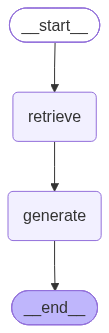

In [29]:
#Visualize graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Test Manually

In [30]:
preferences = "I want a low risk investment portfolio."
llm_graph = get_llm("GPT-OSS-120B (Groq)", 0.7)
result = graph.invoke({"preferences": preferences})
print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(id='3d56aeb8-b5d9-44e1-9e85-5ea5a23dac43', metadata={'scheme_type': 'Open Ended Schemes', 'scheme_category': 'Equity Scheme - Small Cap Fund'}, page_content='Scheme Name: quant Small Cap Fund - IDCW Option - Regular Plan\nFund House: quant Mutual Fund\nScheme Type: Open Ended Schemes\nScheme Category: Equity Scheme - Small Cap Fund\nNet Asset Value: 141.0509\nDate: 27-10-2023'), Document(id='add21789-8d84-4d68-8c96-0089ac338f01', metadata={'scheme_type': 'Open Ended Schemes', 'scheme_category': 'Equity Scheme - Small Cap Fund'}, page_content='Scheme Name: quant Small Cap Fund - IDCW Option - Regular Plan\nFund House: quant Mutual Fund\nScheme Type: Open Ended Schemes\nScheme Category: Equity Scheme - Small Cap Fund\nNet Asset Value: 141.0509\nDate: 27-10-2023'), Document(id='7a50d770-0b89-4408-b91c-4e065bb61b72', metadata={'scheme_category': 'Debt Scheme - Low Duration Fund', 'scheme_type': 'Open Ended Schemes'}, page_content='Scheme Name: LIC MF Low Duration Fund-Re

## User Interface

In [31]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    llm_graph = get_llm(user_input["model_choice"], user_input["temperature"])
    result = graph.invoke({"preferences": preferences})["answer"]
    
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []
    # Build a plain text list of scheme recommendations
    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [32]:
# Gradio Blocks layout
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [33]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
